# Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import os

# Config

In [2]:
BASE = "."
SRC = os.path.join(BASE, "src")
CACHED_FILE = "train.csv"

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# Dataframe Generation

In [3]:
df = pd.read_csv(os.path.join(BASE, CACHED_FILE))
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.shape

(1460, 81)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

| Atribut | Tipe Atribut | Penjelasan |
|---|---|---|
| `Id` | Identifier | Nomor identitas baris, bukan besaran numerik. |
| Atribut kategorikal | Nominal / Ordinal | `MSZoning`, `Neighborhood`, `ExterQual`, dan lainnya. |
| Atribut numerik | Diskret / Kontinu | `LotArea`, `GrLivArea`, `YearBuilt`, dan lainnya. |
| `MSSubClass` | Nominal | Kode tipe bangunan yang disimpan sebagai bilangan bulat. |
| `SalePrice` | Numerik kontinu | Harga jual rumah (target). |

# EDA

## Statistics

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [7]:
df.describe(include="str").T

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


## Missingness

In [8]:
na = df.isna().sum()
na = na[na > 0].sort_values(ascending=False)
na_pct = (na / len(df) * 100).round(2)
pd.DataFrame({"jumlah_hilang": na, "persentase": na_pct})

,jumlah_hilang,persentase
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


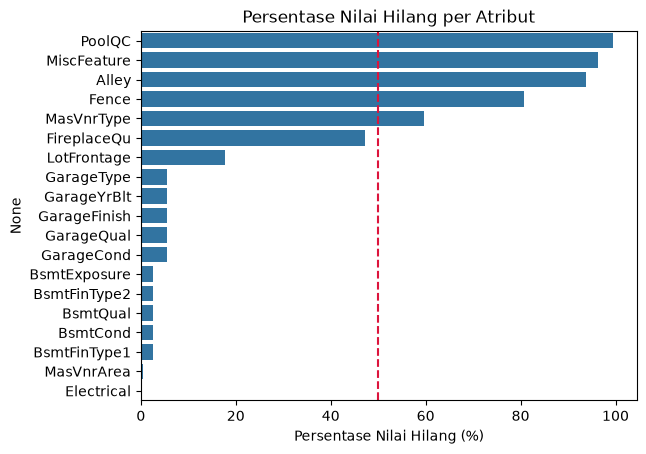

In [9]:
sns.barplot(x=na_pct.values, y=na_pct.index)
plt.axvline(50, color="crimson", ls="--")
plt.xlabel("Persentase Nilai Hilang (%)")
plt.title("Persentase Nilai Hilang per Atribut")
plt.show()

Dari 80 atribut, terdapat 19 atribut dengan nilai hilang. Sebanyak 5 atribut memiliki nilai hilang di atas 50%, yaitu `PoolQC`, `MiscFeature`, `Alley`, `Fence`, dan `MasVnrType`. Atribut-atribut tersebut dibuang karena informasinya terlalu sedikit. Nilai hilang pada atribut lainnya ditangani sesuai makna tiap atribut.

# Praproses

## 1. Penghapusan Atribut dengan Missing > 50%

In [10]:
drop_cols = na_pct[na_pct > 50].index.tolist()
print("Dibuang:", drop_cols)

df = df.drop(columns=drop_cols)
df.shape

Dibuang: ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']


(1460, 76)

## 2. Imputasi Nilai Hilang

In [11]:
# Atribut kategorikal: NaN berarti fasilitas tidak ada -> kategori "None"
none_cols = [
    "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
]
for c in none_cols:
    df[c] = df[c].fillna("None")

# Electrical: hanya 1 nilai kosong -> isi modus
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

# LotFrontage: median per lingkungan
df["LotFrontage"] = (
    df.groupby("Neighborhood")["LotFrontage"]
      .transform(lambda s: s.fillna(s.median()))
      .fillna(df["LotFrontage"].median())
)

# GarageYrBlt: asumsi dibangun bersamaan dengan rumah
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["YearBuilt"])

# MasVnrArea: 0 berarti tidak ada pelapisan batu
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

print("Total nilai hilang tersisa:", df.isna().sum().sum())

Total nilai hilang tersisa: 0


## 3. Deteksi dan Penanganan Outlier

In [12]:
df["MSSubClass"] = df["MSSubClass"].astype(str)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "Id"]

def iqr_outlier_mask(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)

total = sum(iqr_outlier_mask(df[c]).sum() for c in num_cols)
print("Total nilai outlier:", total)

Total nilai outlier: 1563


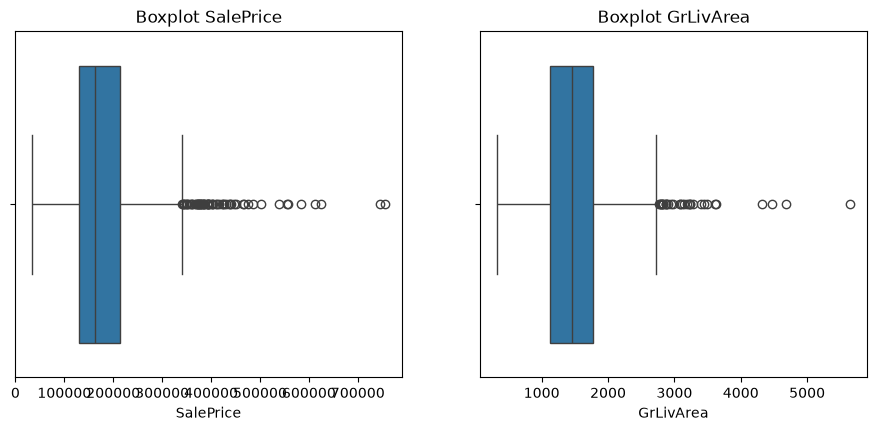

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, c in zip(axes, ["SalePrice", "GrLivArea"]):
    sns.boxplot(x=df[c], ax=ax)
    ax.set_title(f"Boxplot {c}")
plt.show()

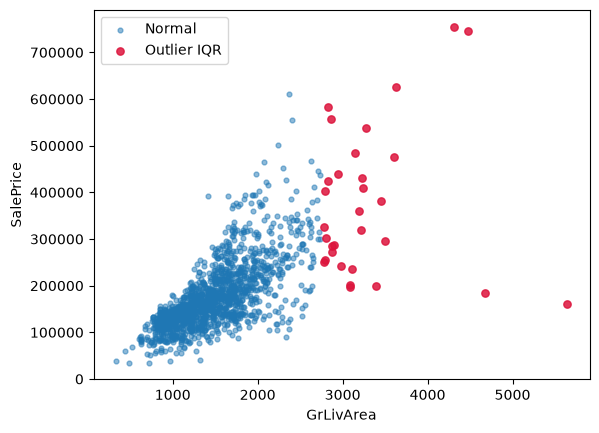

In [14]:
mask = iqr_outlier_mask(df["GrLivArea"])
plt.scatter(df.loc[~mask, "GrLivArea"], df.loc[~mask, "SalePrice"], alpha=0.5, s=12, label="Normal")
plt.scatter(df.loc[mask, "GrLivArea"], df.loc[mask, "SalePrice"], alpha=0.85, s=28, color="crimson", label="Outlier IQR")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.legend()
plt.show()

Outlier tidak dihapus karena merupakan observasi valid (rumah berukuran besar dan bernilai tinggi). Penanganan dilakukan dengan *winsorization* (capping nilai ke batas IQR) dan transformasi logaritmik.

In [15]:
# Winsorization: cap nilai ke batas IQR (kecuali target)
capped = 0
for c in num_cols:
    if c == "SalePrice":
        continue
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    if ((df[c] < lo) | (df[c] > hi)).sum() > 0:
        df[c] = df[c].clip(lo, hi)
        capped += 1
print("Atribut yang di-winsorize:", capped)

Atribut yang di-winsorize: 30


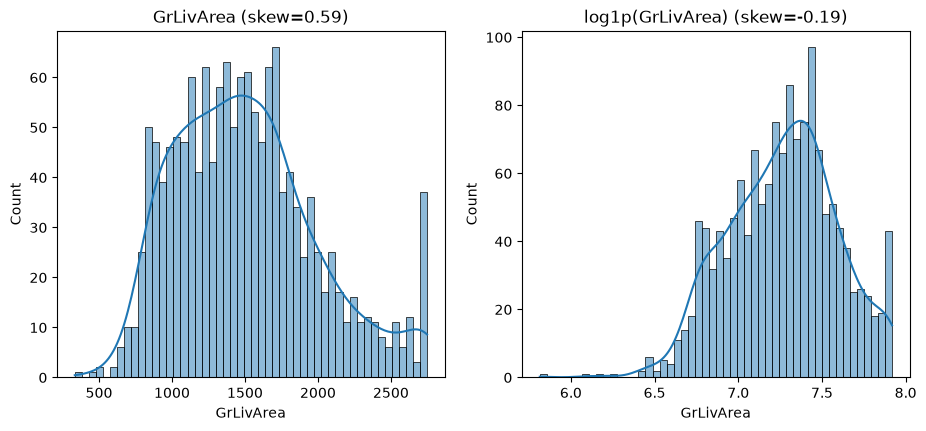

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.histplot(df["GrLivArea"], bins=50, kde=True, ax=axes[0])
axes[0].set_title(f"GrLivArea (skew={df['GrLivArea'].skew():.2f})")
sns.histplot(np.log1p(df["GrLivArea"]), bins=50, kde=True, ax=axes[1])
axes[1].set_title(f"log1p(GrLivArea) (skew={np.log1p(df['GrLivArea']).skew():.2f})")
plt.show()

## 4. Transformasi Data

### 4.1 Transformasi Logaritmik

In [17]:
skewed = [c for c in num_cols if c != "SalePrice" and df[c].skew() > 0.75]
print("Atribut menceng:", skewed)

for c in skewed:
    if (df[c] >= 0).all():
        df[c] = np.log1p(df[c])

Atribut menceng: ['MasVnrArea', 'BsmtUnfSF', '2ndFlrSF', 'WoodDeckSF', 'OpenPorchSF']


### 4.2 Standarisasi (z-score)

In [18]:
feat_num = [c for c in num_cols if c != "SalePrice"]
scaler = StandardScaler()
df[feat_num] = scaler.fit_transform(df[feat_num])
df[feat_num].describe().loc[["mean", "std"]].T.head()

,mean,std
LotFrontage,1.812857e-16,1.000343
LotArea,5.535907e-17,1.000343
OverallQual,-2.287364e-16,1.000343
OverallCond,-4.355724e-16,1.000343
YearBuilt,1.178966e-15,1.000343


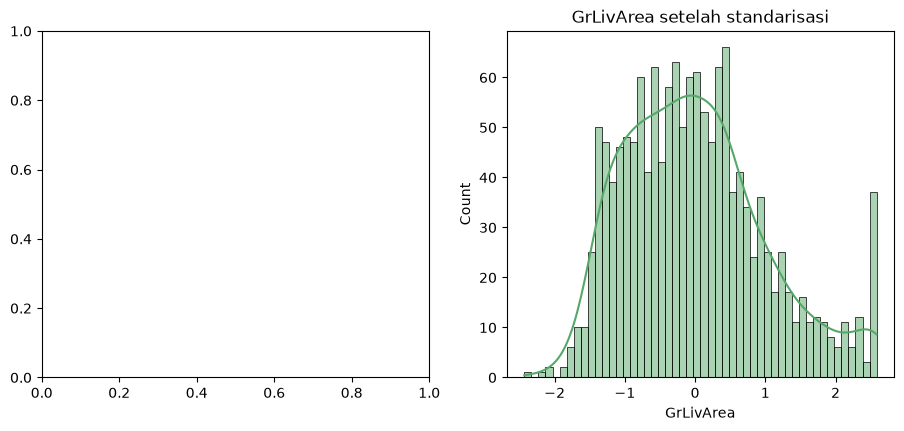

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.histplot(df["GrLivArea"], bins=50, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("GrLivArea setelah standarisasi")
plt.show()

### 4.3 One-Hot Encoding

In [20]:
cat_cols = df.select_dtypes(include=["str", "object"]).columns.tolist()
print("Jumlah atribut kategorikal:", len(cat_cols))

df_enc = pd.get_dummies(df, columns=cat_cols, dtype=float).drop(columns=["Id"])
print("Shape setelah encoding:", df_enc.shape)

Jumlah atribut kategorikal: 39
Shape setelah encoding: (1460, 296)


## 5. Reduksi Dimensi

### 5.1 Analisis Korelasi

In [21]:
num_enc = df_enc.select_dtypes(include=[np.number]).columns.tolist()
corr_vals = df_enc[num_enc].corr().abs().to_numpy()
cols = list(num_enc)
mask = np.triu(np.ones(corr_vals.shape), k=1).astype(bool)
ii, jj = np.where((corr_vals > 0.90) & mask)
pairs = [(cols[j], cols[i], corr_vals[i, j]) for i, j in zip(ii, jj)]
print("Pasangan korelasi > 0.90:", len(pairs))
for c, r, v in sorted(pairs, key=lambda x: -x[2])[:10]:
    print(f"  {r:20s} - {c:20s} {v:.3f}")

to_drop = sorted({c for c, r, v in pairs})
df_red = df_enc.drop(columns=to_drop)
print("Shape setelah pemangkasan:", df_red.shape)

Pasangan korelasi > 0.90: 34
  MSSubClass_90        - BldgType_Duplex      1.000
  Street_Grvl          - Street_Pave          1.000
  Utilities_AllPub     - Utilities_NoSeWa     1.000
  Exterior1st_CBlock   - Exterior2nd_CBlock   1.000
  BsmtQual_None        - BsmtCond_None        1.000
  BsmtQual_None        - BsmtFinType1_None    1.000
  BsmtCond_None        - BsmtFinType1_None    1.000
  CentralAir_N         - CentralAir_Y         1.000
  GarageType_None      - GarageFinish_None    1.000
  GarageType_None      - GarageQual_None      1.000
Shape setelah pemangkasan: (1460, 271)


### 5.2 Principal Component Analysis (PCA)

In [22]:
X = df_red.drop(columns=["SalePrice"]).astype(float)
Xs = StandardScaler().fit_transform(X)

pca = PCA().fit(Xs)
evr = pca.explained_variance_ratio_
cumevr = np.cumsum(evr)
print("PC1 evr:", round(evr[0], 4))
print("Komponen untuk 90% varians:", int(np.argmax(cumevr >= 0.90) + 1))

PC1 evr: 0.066
Komponen untuk 90% varians: 144


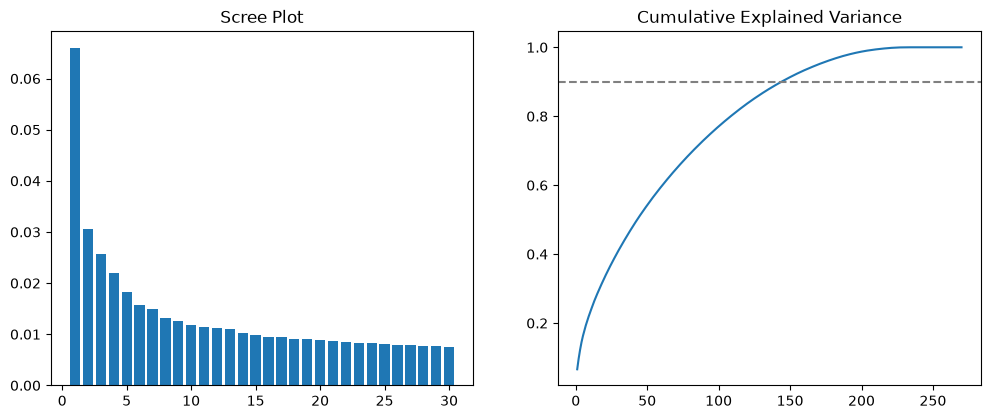

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].bar(range(1, 31), evr[:30])
axes[0].set_title("Scree Plot")
axes[1].plot(range(1, len(cumevr) + 1), cumevr)
axes[1].axhline(0.90, color="gray", ls="--")
axes[1].set_title("Cumulative Explained Variance")
plt.show()

## 6. Dataset Akhir

In [24]:
final = df_enc.copy()
final.to_csv("5054251028_Malfino Muhammad Willianz_Tugas_Praproses_Data.csv", index=False)
print("Dataset akhir tersimpan dengan shape:", final.shape)

Dataset akhir tersimpan dengan shape: (1460, 296)
